In [ ]:
pip install yfinance pandas matplotlib seaborn


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Define the tickers
tickers = ['AAPL', 'MSFT', 'GOOG']

# Download historical data (adjust period as needed)
data = yf.download(tickers, start='2020-01-01', end='2023-12-31', group_by='ticker', auto_adjust=True)


[*********************100%***********************]  3 of 3 completed


In [ ]:
# Step 4: Restructure the data
all_data = []

for ticker in tickers:
    df = data[ticker].copy()
    df['Ticker'] = ticker
    df['Date'] = df.index
    all_data.append(df)

# Combine all ticker data into a single DataFrame
df_all = pd.concat(all_data)
df_all.reset_index(drop=True, inplace=True)


In [ ]:
# Step 5: Add technical indicators
df_all['MA10'] = df_all.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=10).mean())
df_all['MA50'] = df_all.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=50).mean())
df_all['Daily Return'] = df_all.groupby('Ticker')['Close'].transform(lambda x: x.pct_change())


In [ ]:
# Step 6: Check the data
print(df_all[['Ticker', 'Date', 'Close', 'MA10', 'MA50', 'Daily Return']].head(15))


Price Ticker       Date      Close       MA10  MA50  Daily Return
0       AAPL 2020-01-02  72.716072        NaN   NaN           NaN
1       AAPL 2020-01-03  72.009102        NaN   NaN     -0.009722
2       AAPL 2020-01-06  72.582924        NaN   NaN      0.007969
3       AAPL 2020-01-07  72.241554        NaN   NaN     -0.004703
4       AAPL 2020-01-08  73.403648        NaN   NaN      0.016086
5       AAPL 2020-01-09  74.962807        NaN   NaN      0.021241
6       AAPL 2020-01-10  75.132256        NaN   NaN      0.002260
7       AAPL 2020-01-13  76.737434        NaN   NaN      0.021365
8       AAPL 2020-01-14  75.701218        NaN   NaN     -0.013503
9       AAPL 2020-01-15  75.376785  74.086380   NaN     -0.004286
10      AAPL 2020-01-16  76.320999  74.446873   NaN      0.012527
11      AAPL 2020-01-17  77.165955  74.962558   NaN      0.011071
12      AAPL 2020-01-21  76.643013  75.368567   NaN     -0.006777
13      AAPL 2020-01-22  76.916595  75.836071   NaN      0.003570
14      AA

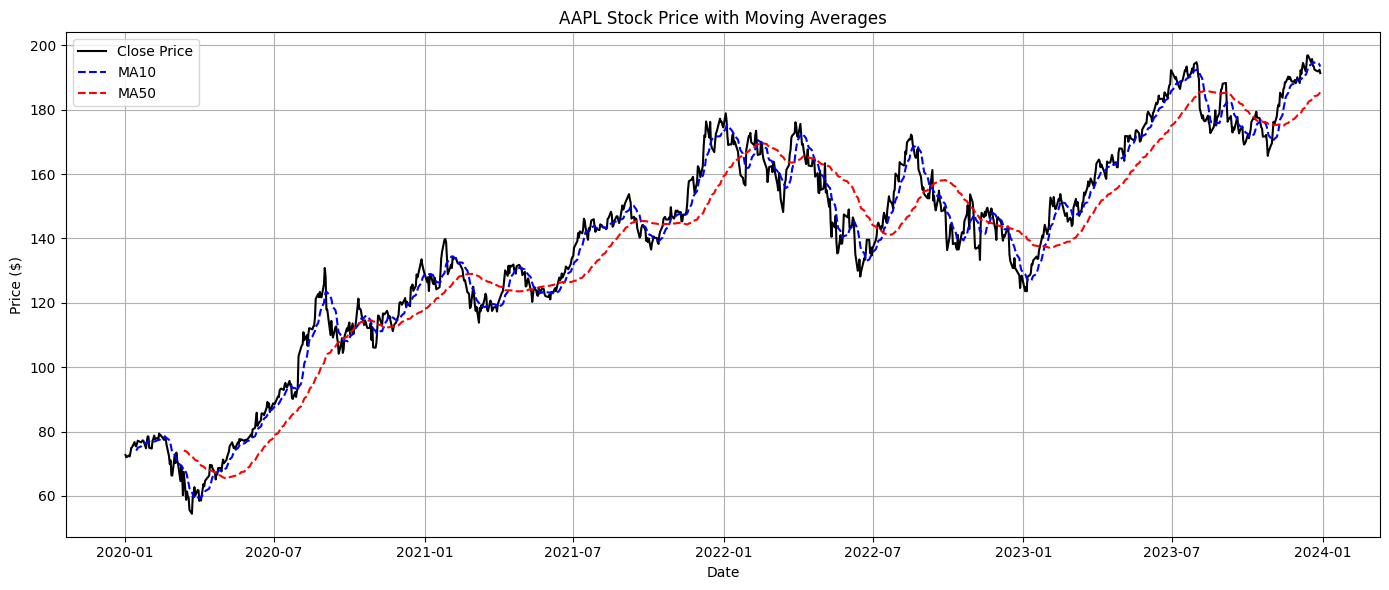

In [ ]:
import matplotlib.pyplot as plt

# Step 7: Plot for a single stock
def plot_stock(ticker):
    df_plot = df_all[df_all['Ticker'] == ticker]

    plt.figure(figsize=(14, 6))
    plt.plot(df_plot['Date'], df_plot['Close'], label='Close Price', color='black')
    plt.plot(df_plot['Date'], df_plot['MA10'], label='MA10', color='blue', linestyle='--')
    plt.plot(df_plot['Date'], df_plot['MA50'], label='MA50', color='red', linestyle='--')

    plt.title(f'{ticker} Stock Price with Moving Averages')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call it for AAPL
plot_stock('AAPL')


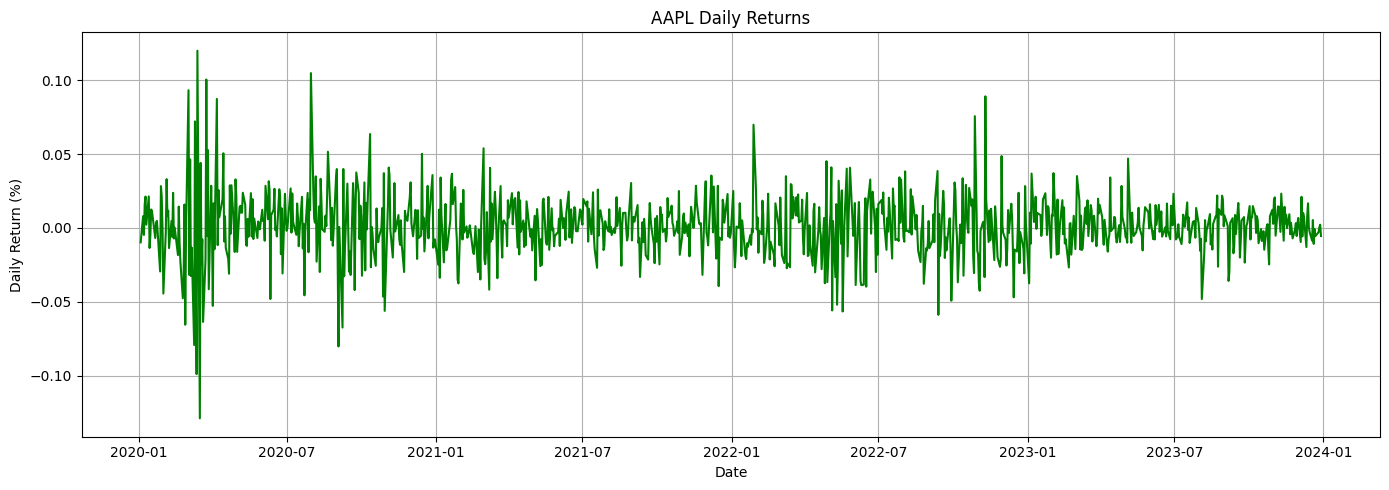

In [ ]:
def plot_daily_returns(ticker):
    df_plot = df_all[df_all['Ticker'] == ticker]

    plt.figure(figsize=(14, 5))
    plt.plot(df_plot['Date'], df_plot['Daily Return'], color='green')
    plt.title(f'{ticker} Daily Returns')
    plt.xlabel('Date')
    plt.ylabel('Daily Return (%)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_daily_returns('AAPL')


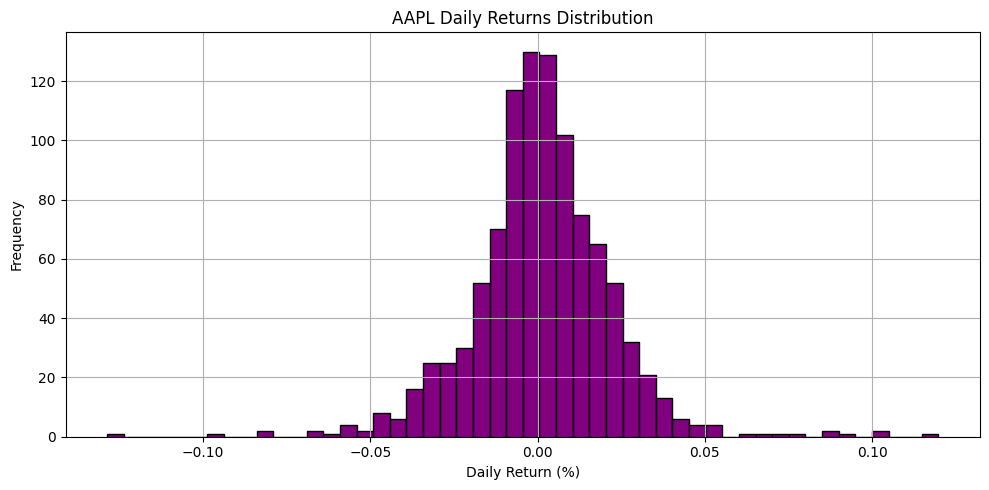

In [ ]:
def hist_daily_returns(ticker):
    df_plot = df_all[df_all['Ticker'] == ticker]

    plt.figure(figsize=(10, 5))
    plt.hist(df_plot['Daily Return'].dropna(), bins=50, color='purple', edgecolor='black')
    plt.title(f'{ticker} Daily Returns Distribution')
    plt.xlabel('Daily Return (%)')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

hist_daily_returns('AAPL')


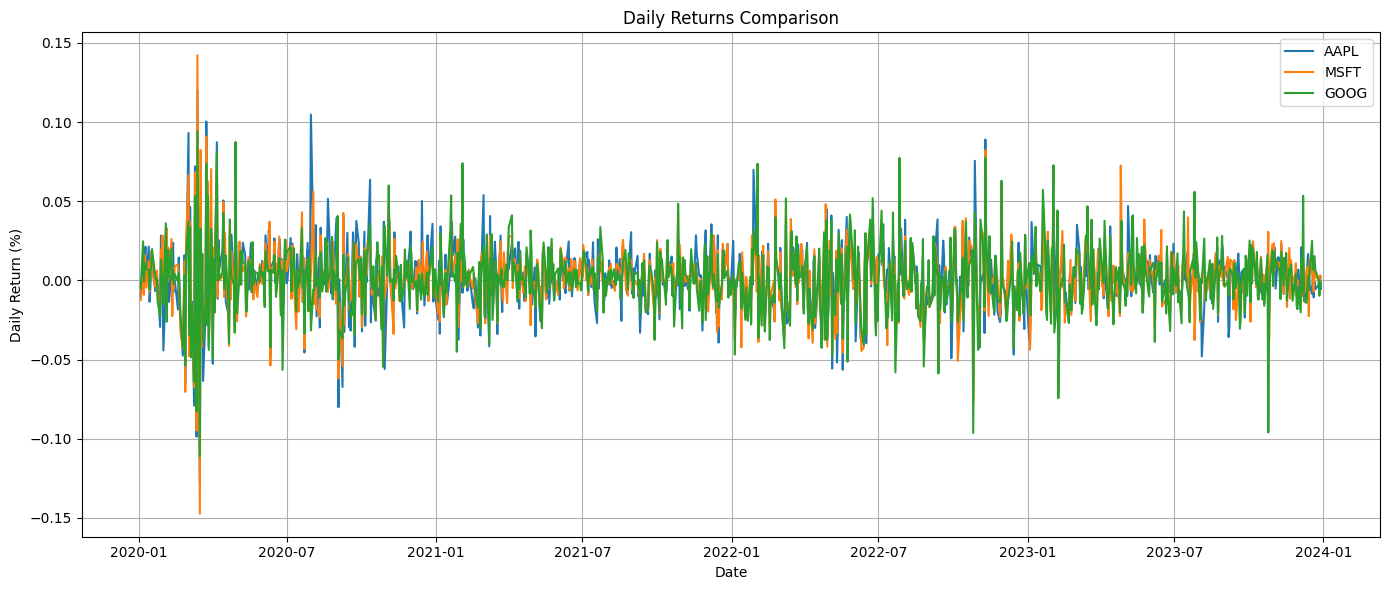

In [ ]:
def compare_daily_returns(tickers):
    plt.figure(figsize=(14, 6))

    for ticker in tickers:
        df_ticker = df_all[df_all['Ticker'] == ticker]
        plt.plot(df_ticker['Date'], df_ticker['Daily Return'], label=ticker)

    plt.title('Daily Returns Comparison')
    plt.xlabel('Date')
    plt.ylabel('Daily Return (%)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

compare_daily_returns(['AAPL', 'MSFT', 'GOOG'])


Environment 1: Simple Moving Average (SMA) Crossover Strategy.

In [ ]:
pip install gym numpy pandas matplotlib


In [ ]:
import gym
from gym import spaces
import numpy as np
import pandas as pd

class SmaTradingEnv(gym.Env):
    def __init__(self, df, window_size=10, initial_balance=10000):
        super(SmaTradingEnv, self).__init__()

        self.df = df.reset_index()
        self.window_size = window_size
        self.initial_balance = initial_balance
        self.action_space = spaces.Discrete(3)  # 0 = Hold, 1 = Buy, 2 = Sell
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(window_size, 2), dtype=np.float32)

        self._reset()

    def _reset(self):
        self.balance = self.initial_balance
        self.position = 0  # 0 = no position, 1 = long
        self.start_index = self.window_size
        self.current_step = self.start_index
        self.total_profit = 0
        self.trades = []
        return self._get_observation()

    def reset(self):
        return self._reset()

    def _get_observation(self):
        frame = self.df.iloc[self.current_step - self.window_size:self.current_step]
        obs = frame[['Close', 'MA10']].values
        return obs.astype(np.float32)

    def step(self, action):
        reward = 0
        done = False
        price = self.df.iloc[self.current_step]['Close']

        if action == 1:  # Buy
            if self.position == 0:
                self.position = price
        elif action == 2:  # Sell
            if self.position != 0:
                profit = price - self.position
                reward += profit
                self.total_profit += profit
                self.position = 0

        self.current_step += 1
        if self.current_step >= len(self.df):
            done = True

        obs = self._get_observation()
        return obs, reward, done, {}

    def render(self):
        print(f'Step: {self.current_step}, Profit: {self.total_profit}')


In [ ]:
env_code = """
import gym
from gym import spaces
import numpy as np

class SmaTradingEnv(gym.Env):
    def __init__(self, df):
        super(SmaTradingEnv, self).__init__()
        self.df = df.reset_index(drop=True)
        self.current_step = 0
        self.initial_balance = 10000
        self.balance = self.initial_balance
        self.position = 0
        self.total_profit = 0
        self.max_steps = len(df) - 1

        self.action_space = spaces.Discrete(3)  # 0: Hold, 1: Buy, 2: Sell
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(3,), dtype=np.float32
        )

    def reset(self):
        self.current_step = 0
        self.balance = self.initial_balance
        self.position = 0
        self.total_profit = 0
        return self._get_obs()

    def _get_obs(self):
        row = self.df.iloc[self.current_step]
        return np.array([row['Close'], row['MA10'], self.position], dtype=np.float32)

    def step(self, action):
        done = False
        reward = 0
        row = self.df.iloc[self.current_step]

        if action == 1 and self.position == 0:  # Buy
            self.position = self.balance / row['Close']
            self.balance = 0
        elif action == 2 and self.position > 0:  # Sell
            self.balance = self.position * row['Close']
            reward = self.balance - self.initial_balance
            self.total_profit += reward
            self.position = 0

        self.current_step += 1
        if self.current_step >= self.max_steps:
            done = True

        return self._get_obs(), reward, done, {}

    def render(self, mode='human'):
        print(f'Step: {self.current_step}, Balance: {self.balance:.2f}, Position: {self.position:.2f}, Total Profit: {self.total_profit:.2f}')
"""

with open("sma_trading_env.py", "w") as f:
    f.write(env_code)



In [ ]:
from sma_trading_env import SmaTradingEnv


In [ ]:
import gym
import matplotlib.pyplot as plt

# Use previously created DataFrame (df_all) with 'Close' and 'MA10'
# We'll just use AAPL data for this test
df_aapl = df_all[df_all['Ticker'] == 'AAPL'].copy()
df_aapl.dropna(inplace=True)  # Drop rows with NaN in indicators

# Initialize the environment
env = SmaTradingEnv(df_aapl)

# Reset and simulate a few steps
obs = env.reset()
print("Initial Observation:", obs)

for _ in range(10):
    action = env.action_space.sample()  # Random action for testing
    obs, reward, done, _ = env.step(action)
    env.render()
    if done:
        break


Initial Observation: [67.4575  68.58012  0.     ]
Step: 1, Balance: 10000.00, Position: 0.00, Total Profit: 0.00
Step: 2, Balance: 10000.00, Position: 0.00, Total Profit: 0.00
Step: 3, Balance: 10000.00, Position: 0.00, Total Profit: 0.00
Step: 4, Balance: 0.00, Position: 167.05, Total Profit: 0.00
Step: 5, Balance: 0.00, Position: 167.05, Total Profit: 0.00
Step: 6, Balance: 0.00, Position: 167.05, Total Profit: 0.00
Step: 7, Balance: 9095.96, Position: 0.00, Total Profit: -904.04
Step: 8, Balance: 9095.96, Position: 0.00, Total Profit: -904.04
Step: 9, Balance: 9095.96, Position: 0.00, Total Profit: -904.04
Step: 10, Balance: 0.00, Position: 145.03, Total Profit: -904.04


RL AGENT: ✅ Step: Train an RL Agent (Using Stable-Baselines3)
We’ll use a simple RL algorithm like PPO (Proximal Policy Optimization) from stable-baselines3.

In [ ]:
!pip install stable-baselines3[extra]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 10.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
!pip install "shimmy>=2.0"


In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# Wrap your environment for vectorized training
env = DummyVecEnv([lambda: SmaTradingEnv(df_aapl)])

# Initialize the PPO agent
model = PPO("MlpPolicy", env, verbose=1)

# Train the model
model.learn(total_timesteps=10000)


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 856  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 569          |
|    iterations           | 2            |
|    time_elapsed         | 7            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0005231146 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.1         |
|    explained_variance   | 3.46e-06     |
|    learning_rate        | 0.0003       |
|    loss                 | 1.94e+08     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00202     |
|    value_loss           | 4.57e+08     |
------------------------------------------

In [ ]:
obs = env.reset()
done = False
total_reward = 0
rewards = []
actions = []
prices = []

while not done:
    action, _states = model.predict(obs)
    obs, reward, done, info = env.step(action)
    total_reward += reward
    rewards.append(reward)
    actions.append(action)
    prices.append(env.envs[0].df.loc[env.envs[0].current_step, 'Close'])

print(f"Total Test Reward: {float(total_reward):.2f}")




Total Test Reward: 619821.56


<ipython-input-24-d2043a731a58>:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Total Test Reward: {float(total_reward):.2f}")


In [ ]:
actions = np.array(actions).flatten()



In [ ]:
prices = np.array(prices).flatten()
rewards = np.array(rewards).flatten()
cumulative_rewards = np.cumsum(rewards)


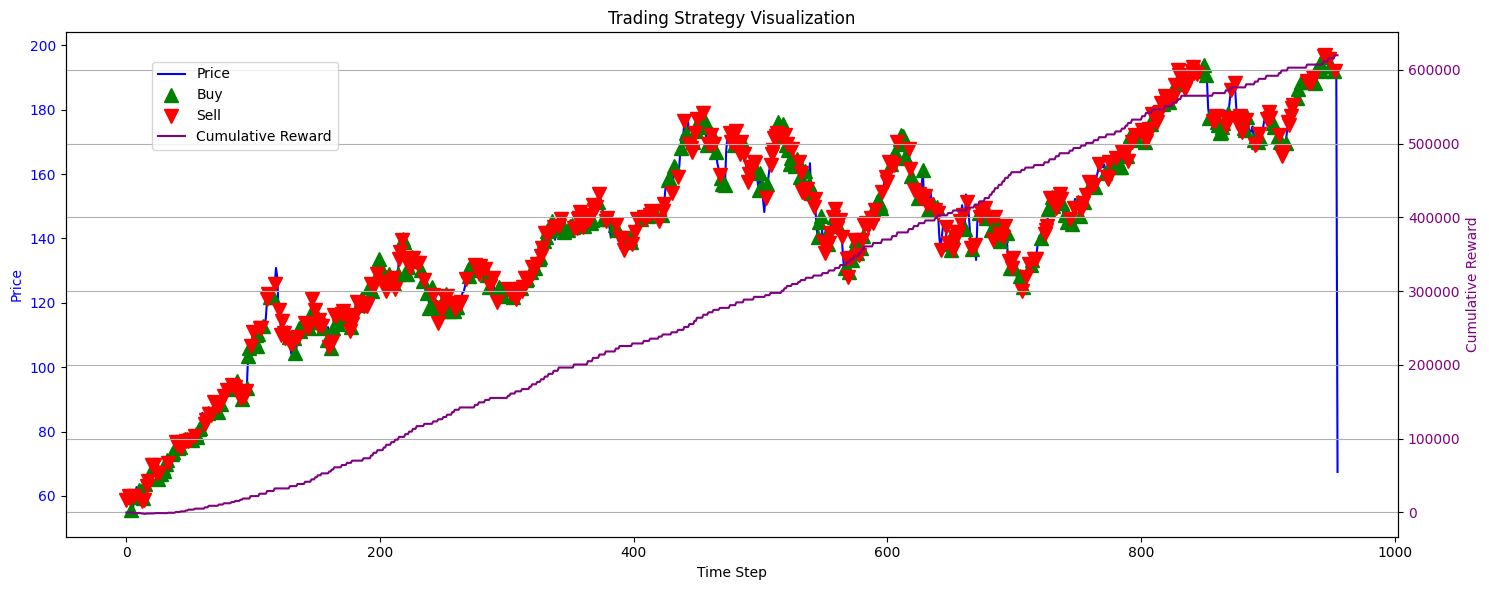

In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 6))

# Price plot
ax1.set_title("Trading Strategy Visualization")
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Price", color='blue')
ax1.plot(prices, label="Price", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Action markers
buy_signals = actions == 1
sell_signals = actions == 2

ax1.plot(np.where(buy_signals)[0], prices[buy_signals], '^', markersize=10, color='green', label='Buy')
ax1.plot(np.where(sell_signals)[0], prices[sell_signals], 'v', markersize=10, color='red', label='Sell')

# Cumulative reward on twin axis
ax2 = ax1.twinx()
ax2.set_ylabel("Cumulative Reward", color='purple')
ax2.plot(cumulative_rewards, label="Cumulative Reward", color='purple')
ax2.tick_params(axis='y', labelcolor='purple')

# Final touches
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.grid()
plt.tight_layout()
plt.show()


Environment 2: CryptoMultiAssetTradingEnv

📊 Assets:
You’ll trade a portfolio of cryptocurrencies — for example:

Bitcoin (BTC)

Ethereum (ETH)

Solana (SOL) (optional for more complexity)

🧠 Observations:
At each time step, the agent sees:

Current prices (normalized)

Price history (e.g., last 10 days)

Technical indicators (SMA, RSI, etc.)

Portfolio state: current holdings & cash

🎮 Actions:
A vector of actions, one for each asset:

0 = Sell

1 = Hold

2 = Buy
Or alternatively, use continuous action space for fractional buys/sells.

💸 Rewards:
Change in portfolio value

Penalize excessive trades to simulate transaction costs

💼 Portfolio Mechanics:
Start with fixed cash (e.g., $10,000)

Track:

Asset allocations

Net portfolio value

Daily PnL (Profit and Loss)

Apply transaction fees (e.g., 0.1%)

⚙️ Features:
Multi-asset support

Realistic crypto volatility

Optional: Leverage or shorting

Can be extended with risk metrics (Sharpe ratio, max drawdown, etc.)

✅ Goals:
Build a robust agent that can learn optimal asset allocation.

Maximize returns while minimizing transaction costs and risks.

In [ ]:
pip install yfinance pandas


 Fetch Historical Crypto Data

In [ ]:
import yfinance as yf
import pandas as pd

# Define the ticker symbols for cryptocurrencies
crypto_tickers = ['BTC-USD', 'ETH-USD', 'LTC-USD']

# Define the time period and interval
start_date = '2023-01-01'
end_date = '2025-01-01'
interval = '1d'  # Daily data

# Download the data
crypto_data = yf.download(crypto_tickers, start=start_date, end=end_date, interval=interval)

# Display the first few rows of the data
print(crypto_data.head())


[                       0%                       ]

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  3 of 3 completed

Price              Close                                  High               \
Ticker           BTC-USD      ETH-USD    LTC-USD       BTC-USD      ETH-USD   
Date                                                                          
2023-01-01  16625.080078  1200.964844  70.815659  16630.439453  1203.475342   
2023-01-02  16688.470703  1214.656616  74.862907  16759.343750  1219.860596   
2023-01-03  16679.857422  1214.778809  75.602722  16760.447266  1219.095337   
2023-01-04  16863.238281  1256.526611  75.433907  16964.585938  1264.807495   
2023-01-05  16836.736328  1250.438599  74.250809  16884.021484  1258.571533   

Price                           Low                                  Open  \
Ticker        LTC-USD       BTC-USD      ETH-USD    LTC-USD       BTC-USD   
Date                                                                        
2023-01-01  71.328911  16521.234375  1192.885376  69.234886  16547.914062   
2023-01-02  75.755173  16572.228516  1195.214966  70.227379

Save Data to CSV

In [ ]:
import yfinance as yf
import pandas as pd

crypto_tickers = ['BTC-USD', 'ETH-USD', 'LTC-USD']
start_date = '2023-01-01'
end_date = '2025-01-01'
interval = '1d'

# Download crypto data
crypto_data = yf.download(crypto_tickers, start=start_date, end=end_date, interval=interval)

# Save only the 'Close' prices
for ticker in crypto_tickers:
    try:
        close_data = crypto_data['Close'][ticker].dropna()
        close_data.name = 'Close'
        close_data = close_data.reset_index()
        close_data.to_csv(f'{ticker}_close_data.csv', index=False)
        print(f"✅ Saved Close price data for {ticker}")
    except KeyError:
        print(f"⚠️ 'Close' data not found for {ticker}")




[*********************100%***********************]  3 of 3 completed

✅ Saved Close price data for BTC-USD
✅ Saved Close price data for ETH-USD
✅ Saved Close price data for LTC-USD


In [ ]:
print(crypto_data.columns)

MultiIndex([( 'Close', 'BTC-USD'),
            ( 'Close', 'ETH-USD'),
            ( 'Close', 'LTC-USD'),
            (  'High', 'BTC-USD'),
            (  'High', 'ETH-USD'),
            (  'High', 'LTC-USD'),
            (   'Low', 'BTC-USD'),
            (   'Low', 'ETH-USD'),
            (   'Low', 'LTC-USD'),
            (  'Open', 'BTC-USD'),
            (  'Open', 'ETH-USD'),
            (  'Open', 'LTC-USD'),
            ('Volume', 'BTC-USD'),
            ('Volume', 'ETH-USD'),
            ('Volume', 'LTC-USD')],
           names=['Price', 'Ticker'])


 custom Crypto Market Environment (Environment 2) from scratch using gym.Env.

In [ ]:
import gym
from gym import spaces
import numpy as np
import pandas as pd

class CryptoTradingEnv(gym.Env):
    def __init__(self, btc_data, eth_data, ltc_data, initial_balance=10000):
        super(CryptoTradingEnv, self).__init__()

        self.initial_balance = initial_balance
        self.btc_data = btc_data.reset_index(drop=True)
        self.eth_data = eth_data.reset_index(drop=True)
        self.ltc_data = ltc_data.reset_index(drop=True)
        self.data_len = len(self.btc_data)

        self.action_space = spaces.MultiDiscrete([3, 3, 3])  # 0: Hold, 1: Buy, 2: Sell for each crypto

        # Observation: prices of 3 coins + balance + holdings of each
        self.observation_space = spaces.Box(low=0, high=np.inf, shape=(7,), dtype=np.float32)

        self.reset()

    def reset(self):
        self.current_step = 0
        self.balance = self.initial_balance
        self.holdings = {'BTC': 0, 'ETH': 0, 'LTC': 0}
        self.net_worth = self.initial_balance
        return self._get_observation()

    def _get_prices(self):
        return {
            'BTC': self.btc_data.loc[self.current_step],
            'ETH': self.eth_data.loc[self.current_step],
            'LTC': self.ltc_data.loc[self.current_step],
        }

    def _get_observation(self):
        prices = self._get_prices()
        obs = [
            prices['BTC'], prices['ETH'], prices['LTC'],
            self.balance,
            self.holdings['BTC'], self.holdings['ETH'], self.holdings['LTC'],
        ]
        return np.array(obs, dtype=np.float32)

    def step(self, action):
        prices = self._get_prices()

        for idx, coin in enumerate(['BTC', 'ETH', 'LTC']):
            price = prices[coin]
            if action[idx] == 1:  # Buy
                if self.balance > price:
                    self.holdings[coin] += 1
                    self.balance -= price
            elif action[idx] == 2:  # Sell
                if self.holdings[coin] > 0:
                    self.holdings[coin] -= 1
                    self.balance += price

        self.current_step += 1
        done = self.current_step >= self.data_len - 1

        self.net_worth = self.balance + sum([
            self.holdings['BTC'] * prices['BTC'],
            self.holdings['ETH'] * prices['ETH'],
            self.holdings['LTC'] * prices['LTC'],
        ])

        reward = self.net_worth - self.initial_balance

        return self._get_observation(), reward, done, {}



In [ ]:
# Already fetched using yfinance
btc = df[('Close', 'BTC-USD')].dropna().reset_index(drop=True)
eth = df[('Close', 'ETH-USD')].dropna().reset_index(drop=True)
ltc = df[('Close', 'LTC-USD')].dropna().reset_index(drop=True)



KeyError: ('Close', 'BTC-USD')

In [ ]:
print(df.columns)



Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Ticker', 'Date'], dtype='object', name='Price')


In [ ]:
# Assuming df is the full DataFrame with all tickers
btc = df[df['Ticker'] == 'BTC-USD']['Close'].reset_index(drop=True)
eth = df[df['Ticker'] == 'ETH-USD']['Close'].reset_index(drop=True)
ltc = df[df['Ticker'] == 'LTC-USD']['Close'].reset_index(drop=True)


In [ ]:
import yfinance as yf
import pandas as pd

# Download historical data
tickers = ['BTC-USD', 'ETH-USD', 'LTC-USD']
data = yf.download(tickers, start="2020-01-01", end="2023-01-01")['Close']

# Convert to long format
df = data.reset_index().melt(id_vars='Date', var_name='Ticker', value_name='Close')

# Add placeholder columns to match expected format
df['Open'] = 0
df['High'] = 0
df['Low'] = 0
df['Volume'] = 0

# Rearrange columns
df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker']]

# Save it
df.to_csv("crypto_data.csv", index=False)



[*********************100%***********************]  3 of 3 completed


In [ ]:
df = pd.read_csv("crypto_data.csv")

btc = df[df['Ticker'] == 'BTC-USD']['Close'].reset_index(drop=True)
eth = df[df['Ticker'] == 'ETH-USD']['Close'].reset_index(drop=True)
ltc = df[df['Ticker'] == 'LTC-USD']['Close'].reset_index(drop=True)


🧠 Goal:
Create a custom reinforcement learning environment that simulates a crypto market using BTC, ETH, and LTC prices. The agent will learn to buy, sell, or hold each of the three assets.

Define the Environment Skeleton

In [ ]:
import gym
from gym import spaces
import numpy as np

class CryptoTradingEnv(gym.Env):
    def __init__(self, btc, eth, ltc, initial_balance=1000):
        super(CryptoTradingEnv, self).__init__()

        self.btc = btc
        self.eth = eth
        self.ltc = ltc
        self.n_steps = len(btc)
        self.initial_balance = initial_balance

        # 3 assets: BTC, ETH, LTC; each can be bought/sold/held
        self.action_space = spaces.MultiDiscrete([3, 3, 3])  # 0 = hold, 1 = buy, 2 = sell

        # Observation: current prices and portfolio (cash + holdings)
        self.observation_space = spaces.Box(low=0, high=np.inf, shape=(6,), dtype=np.float32)

    def reset(self):
        self.step_idx = 0
        self.balance = self.initial_balance
        self.holdings = {'BTC': 0, 'ETH': 0, 'LTC': 0}
        return self._get_obs()

    def _get_obs(self):
        return np.array([
            self.btc[self.step_idx],
            self.eth[self.step_idx],
            self.ltc[self.step_idx],
            self.holdings['BTC'],
            self.holdings['ETH'],
            self.holdings['LTC']
        ], dtype=np.float32)

    def step(self, action):
        btc_price = self.btc[self.step_idx]
        eth_price = self.eth[self.step_idx]
        ltc_price = self.ltc[self.step_idx]

        # Action interpretation
        for idx, coin, price in zip(range(3), ['BTC', 'ETH', 'LTC'], [btc_price, eth_price, ltc_price]):
            if action[idx] == 1 and self.balance >= price:
                self.holdings[coin] += 1
                self.balance -= price
            elif action[idx] == 2 and self.holdings[coin] > 0:
                self.holdings[coin] -= 1
                self.balance += price

        self.step_idx += 1
        done = self.step_idx >= self.n_steps - 1
        reward = self.balance + sum(self.holdings[c] * p for c, p in zip(['BTC', 'ETH', 'LTC'], [btc_price, eth_price, ltc_price]))
        obs = self._get_obs()
        return obs, reward, done, {}

    def render(self, mode='human'):
        print(f"Step: {self.step_idx}")
        print(f"Balance: {self.balance}")
        print(f"Holdings: {self.holdings}")


Step 2: Initialize and test the environment

In [ ]:
env = CryptoTradingEnv(btc, eth, ltc)

obs = env.reset()
done = False

while not done:
    action = env.action_space.sample()
    obs, reward, done, info = env.step(action)
    env.render()


Step: 1
Balance: 869.197998046875
Holdings: {'BTC': 0, 'ETH': 1, 'LTC': 0}
Step: 2
Balance: 829.3749847412109
Holdings: {'BTC': 0, 'ETH': 1, 'LTC': 1}
Step: 3
Balance: 652.7877044677734
Holdings: {'BTC': 0, 'ETH': 2, 'LTC': 2}
Step: 4
Balance: 517.7183380126953
Holdings: {'BTC': 0, 'ETH': 3, 'LTC': 2}
Step: 5
Balance: 561.2715454101562
Holdings: {'BTC': 0, 'ETH': 3, 'LTC': 1}
Step: 6
Balance: 371.15103912353516
Holdings: {'BTC': 0, 'ETH': 4, 'LTC': 2}
Step: 7
Balance: 324.72645568847656
Holdings: {'BTC': 0, 'ETH': 4, 'LTC': 3}
Step: 8
Balance: 279.0726890563965
Holdings: {'BTC': 0, 'ETH': 4, 'LTC': 4}
Step: 9
Balance: 233.85675811767578
Holdings: {'BTC': 0, 'ETH': 4, 'LTC': 5}
Step: 10
Balance: 41.165653228759766
Holdings: {'BTC': 0, 'ETH': 5, 'LTC': 6}
Step: 11
Balance: 184.0927619934082
Holdings: {'BTC': 0, 'ETH': 4, 'LTC': 6}
Step: 12
Balance: 278.8859558105469
Holdings: {'BTC': 0, 'ETH': 3, 'LTC': 7}
Step: 13
Balance: 328.61972427368164
Holdings: {'BTC': 0, 'ETH': 3, 'LTC': 6}
Step

Add Transaction Costs to Your Environment.
modify the CryptoTradingEnv to include a simple transaction fee

In [ ]:
class CryptoTradingEnv(gym.Env):
    def __init__(self, btc, eth, ltc, transaction_fee=0.001):
        super(CryptoTradingEnv, self).__init__()
        self.btc = btc.values
        self.eth = eth.values
        self.ltc = ltc.values
        self.n_steps = len(btc)
        self.transaction_fee = transaction_fee

        self.action_space = spaces.Discrete(3)  # 0: hold, 1: buy, 2: sell
        self.observation_space = spaces.Box(low=0, high=np.inf, shape=(3,), dtype=np.float32)

    def reset(self):
        self.current_step = 0
        self.holding = False
        self.entry_price = 0
        self.cash = 10000
        self.crypto = 0
        return self._get_obs()

    def _get_obs(self):
        return np.array([
            self.btc[self.current_step],
            self.eth[self.current_step],
            self.ltc[self.current_step]
        ], dtype=np.float32)

    def step(self, action):
        price = self.btc[self.current_step]
        reward = 0

        if action == 1 and not self.holding:  # Buy
            self.crypto = (self.cash * (1 - self.transaction_fee)) / price
            self.cash = 0
            self.holding = True
            self.entry_price = price

        elif action == 2 and self.holding:  # Sell
            self.cash = (self.crypto * price) * (1 - self.transaction_fee)
            reward = self.cash - 10000  # Profit/Loss since start
            self.crypto = 0
            self.holding = False

        self.current_step += 1
        done = self.current_step >= self.n_steps - 1
        obs = self._get_obs()

        return obs, reward, done, {}


Train PPO Agent

In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

env = DummyVecEnv([lambda: CryptoTradingEnv(btc, eth, ltc)])

model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=100_000)


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 1077 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 797           |
|    iterations           | 2             |
|    time_elapsed         | 5             |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00022092092 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.1          |
|    explained_variance   | -1.19e-07     |
|    learning_rate        | 0.0003        |
|    loss                 | 3.37e+08      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.000558     |
|    value_loss           | 8.2e+08       |
-------------------------

 Evaluate and Visualize PPO’s Performance

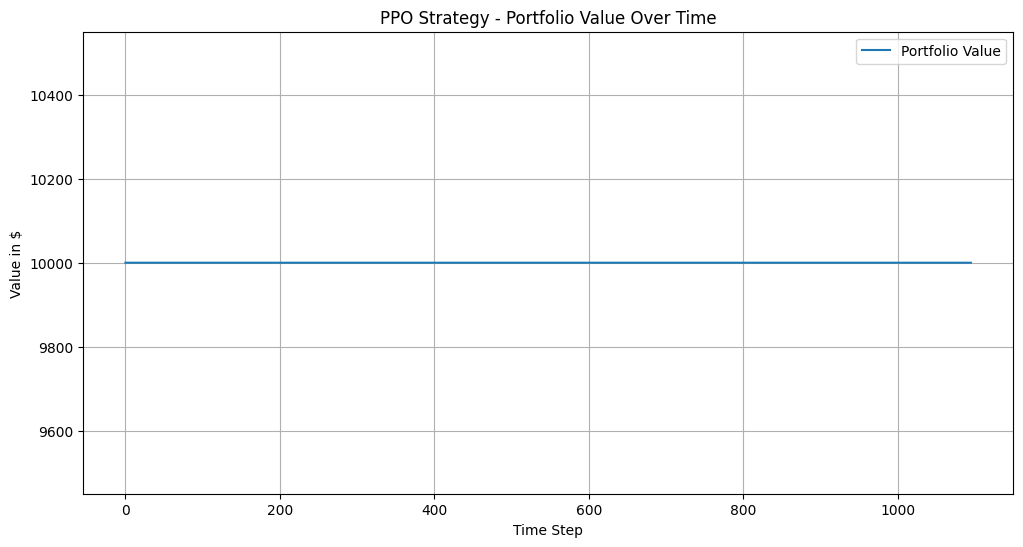

In [ ]:
import matplotlib.pyplot as plt

env = DummyVecEnv([lambda: CryptoTradingEnv(btc, eth, ltc)])
obs = env.reset()
done = False

portfolio_value = []
current_value = 10000

for _ in range(len(btc)):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)

    # Approximate current portfolio value
    step = env.envs[0].current_step
    price = btc[step]
    if env.envs[0].holding:
        current_value = env.envs[0].crypto * price
    else:
        current_value = env.envs[0].cash

    portfolio_value.append(current_value)

plt.figure(figsize=(12, 6))
plt.plot(portfolio_value, label="Portfolio Value")
plt.xlabel("Time Step")
plt.ylabel("Value in $")
plt.title("PPO Strategy - Portfolio Value Over Time")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
def step(self, action):
    done = False
    reward = 0

    # Get current prices
    current_prices = np.array([
        self.btc_data[self.current_step],
        self.eth_data[self.current_step],
        self.ltc_data[self.current_step]
    ])

    # Normalize action to sum to 1 (portfolio weights)
    weights = np.clip(action, 0, 1)
    weights /= np.sum(weights) + 1e-8  # to avoid division by zero

    # Compute total portfolio value
    portfolio_value = (
        self.cash +
        np.sum(self.crypto_held * current_prices)
    )

    # Rebalance portfolio
    target_values = weights * portfolio_value
    target_crypto_held = target_values / current_prices

    # Update holdings
    self.crypto_held = target_crypto_held
    self.cash = 0  # assuming fully invested

    # Move to next step
    self.current_step += 1

    # Compute new portfolio value
    if self.current_step < self.max_steps:
        new_prices = np.array([
            self.btc_data[self.current_step],
            self.eth_data[self.current_step],
            self.ltc_data[self.current_step]
        ])
        new_portfolio_value = np.sum(self.crypto_held * new_prices)
    else:
        done = True
        new_portfolio_value = portfolio_value

    # Reward: change in portfolio value
    reward = new_portfolio_value - portfolio_value

    # Update state
    state = np.array([
        self.btc_data[self.current_step] if self.current_step < self.max_steps else 0,
        self.eth_data[self.current_step] if self.current_step < self.max_steps else 0,
        self.ltc_data[self.current_step] if self.current_step < self.max_steps else 0
    ])

    return state, reward, done, {}


In [ ]:
from gym import Env
from gym.spaces import Box
import numpy as np

class CryptoTradingEnv(Env):
    def __init__(self, btc_data, eth_data, ltc_data):
        super(CryptoTradingEnv, self).__init__()
        self.btc_data = btc_data
        self.eth_data = eth_data
        self.ltc_data = ltc_data
        self.max_steps = len(btc_data) - 1
        self.action_space = Box(low=0, high=1, shape=(3,), dtype=np.float32)
        self.observation_space = Box(low=0, high=np.inf, shape=(3,), dtype=np.float32)

    def reset(self):
        self.current_step = 0
        self.cash = 10000
        self.crypto_held = np.array([0, 0, 0], dtype=np.float32)
        return np.array([
            self.btc_data[self.current_step],
            self.eth_data[self.current_step],
            self.ltc_data[self.current_step]
        ])

    # Make sure the step() function you plugged in earlier is here


In [ ]:
import gym
from gym import spaces
import numpy as np




In [ ]:
class CryptoTradingEnv(gym.Env):
    def __init__(self, btc, eth, ltc):
        super(CryptoTradingEnv, self).__init__()

        self.data = np.stack([btc, eth, ltc], axis=1)
        self.current_step = 0

        self.action_space = spaces.Discrete(3)  # hold, buy, sell
        self.observation_space = spaces.Box(low=0, high=np.inf, shape=(3,), dtype=np.float32)

        self.cash = 1000
        self.crypto_held = np.array([0.0, 0.0, 0.0])

    def reset(self):
        self.current_step = 0
        self.cash = 1000
        self.crypto_held = np.array([0.0, 0.0, 0.0])
        return self.data[self.current_step]

    def step(self, action):
        prices = self.data[self.current_step]

        if action == 1:  # Buy
            self.crypto_held = self.cash / prices
            self.cash = 0
        elif action == 2:  # Sell
            self.cash += np.sum(self.crypto_held * prices)
            self.crypto_held = np.array([0.0, 0.0, 0.0])

        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        next_state = self.data[self.current_step]

        total_value = self.cash + np.sum(self.crypto_held * next_state)
        reward = total_value

        return next_state, reward, done, {}

    def render(self, mode='human'):
        print(f"Step: {self.current_step} | Cash: {self.cash:.2f} | Holdings: {self.crypto_held}")



In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

env = DummyVecEnv([lambda: CryptoTradingEnv(btc, eth, ltc)])

model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=10000)


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 1095 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 812          |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0036803365 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.1         |
|    explained_variance   | 0            |
|    learning_rate        | 0.0003       |
|    loss                 | 9.84e+08     |
|    n_updates            | 10           |
|    policy_gradient_loss | 0.00163      |
|    value_loss           | 1.61e+09     |
------------------------------------------

In [ ]:
model.save("ppo_crypto_trading")



In [ ]:
import os
print("ppo_crypto_trading.zip" in os.listdir())


True


In [ ]:
class CryptoTradingEnv(gym.Env):
    def __init__(self, btc, eth, ltc):
        super(CryptoTradingEnv, self).__init__()
        self.btc = btc
        self.eth = eth
        self.ltc = ltc
        self.current_step = 0
        self.initial_balance = 10000
        self.balance = self.initial_balance
        self.net_worth = self.initial_balance  # ✅ Add this line

        # Example: 3 prices (BTC, ETH, LTC), 1 balance
        self.observation_space = gym.spaces.Box(low=0, high=np.inf, shape=(4,), dtype=np.float32)
        self.action_space = gym.spaces.Discrete(3)  # 0: BTC, 1: ETH, 2: LTC

    def _get_obs(self):
        return np.array([
            self.btc[self.current_step],
            self.eth[self.current_step],
            self.ltc[self.current_step],
            self.balance
        ], dtype=np.float32)

    def reset(self):
        self.current_step = 0
        self.balance = self.initial_balance
        self.net_worth = self.initial_balance  # ✅ Reset net worth
        return self._get_obs()

    def step(self, action):
        current_price = [self.btc, self.eth, self.ltc][action][self.current_step]

        # Dummy strategy: invest 10% of balance
        investment = 0.1 * self.balance
        reward = investment * (np.random.rand() - 0.5)  # Random fluctuation

        self.balance += reward
        self.current_step += 1
        self.net_worth = self.balance  # ✅ Update net worth here

        done = self.current_step >= len(self.btc) - 1
        return self._get_obs(), reward, done, {}



In [ ]:
# Rebuild the environment
env = DummyVecEnv([lambda: CryptoTradingEnv(btc, eth, ltc)])

# Retrain the model
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=10000)
model.save("ppo_crypto_trading")



Using cpu device
-----------------------------
| time/              |      |
|    fps             | 1055 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 719          |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0071559884 |
|    clip_fraction        | 0.00327      |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.1         |
|    explained_variance   | -2.94e-05    |
|    learning_rate        | 0.0003       |
|    loss                 | 2.26e+05     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00091     |
|    value_loss           | 3.62e+05     |
------------------------------------------

In [ ]:
obs = env.reset()
done = False
portfolio_values = []

while not done:
    action, _ = model.predict(obs)
    obs, reward, done, info = env.step(action)
    portfolio_values.append(env.envs[0].net_worth)


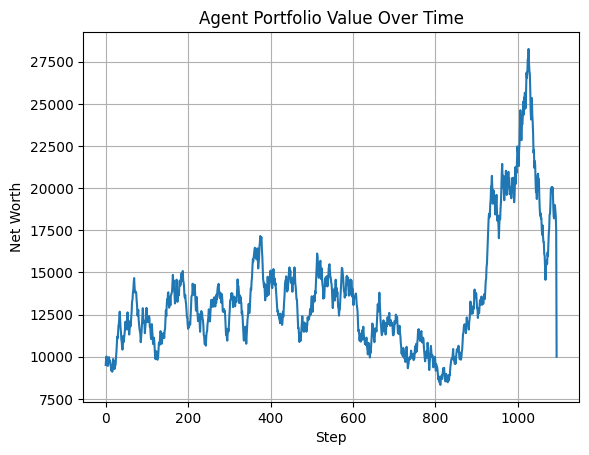

In [ ]:
import matplotlib.pyplot as plt

plt.plot(portfolio_values)
plt.title("Agent Portfolio Value Over Time")
plt.xlabel("Step")
plt.ylabel("Net Worth")
plt.grid(True)
plt.show()


Environment 3: Multi-Asset Portfolio in a Mixed Market


In [ ]:
!pip install stable-baselines3[extra] yfinance gym


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 13.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
import gym
import numpy as np
import pandas as pd
import yfinance as yf
from gym import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv


In [ ]:
assets = ['BTC-USD', 'ETH-USD', 'AAPL', 'MSFT', 'GLD', 'USO']
start_date = '2020-01-01'
end_date = '2023-12-31'

# Download full multi-asset data
data = yf.download(assets, start=start_date, end=end_date, group_by='ticker')

# Show the columns to inspect the structure
print(data.columns.levels)


[*********************100%***********************]  6 of 6 completed

[['AAPL', 'BTC-USD', 'ETH-USD', 'GLD', 'MSFT', 'USO'], ['Close', 'High', 'Low', 'Open', 'Volume']]


In [ ]:
import yfinance as yf
import pandas as pd

assets = ['BTC-USD', 'ETH-USD', 'AAPL', 'MSFT', 'GLD', 'USO']
start_date = '2020-01-01'
end_date = '2023-12-31'

# Download multi-asset data
data = yf.download(assets, start=start_date, end=end_date, group_by='ticker', auto_adjust=False)

# Show first few rows and columns
print("Data shape:", data.shape)
print("Data columns:\n", data.columns)
data.head()



[*********************100%***********************]  6 of 6 completed

Data shape: (1460, 36)
Data columns:
 MultiIndex([(   'MSFT',      'Open'),
            (   'MSFT',      'High'),
            (   'MSFT',       'Low'),
            (   'MSFT',     'Close'),
            (   'MSFT', 'Adj Close'),
            (   'MSFT',    'Volume'),
            ('BTC-USD',      'Open'),
            ('BTC-USD',      'High'),
            ('BTC-USD',       'Low'),
            ('BTC-USD',     'Close'),
            ('BTC-USD', 'Adj Close'),
            ('BTC-USD',    'Volume'),
            ('ETH-USD',      'Open'),
            ('ETH-USD',      'High'),
            ('ETH-USD',       'Low'),
            ('ETH-USD',     'Close'),
            ('ETH-USD', 'Adj Close'),
            ('ETH-USD',    'Volume'),
            (   'AAPL',      'Open'),
            (   'AAPL',      'High'),
            (   'AAPL',       'Low'),
            (   'AAPL',     'Close'),
            (   'AAPL', 'Adj Close'),
            (   'AAPL',    'Volume'),
            (    'USO',      'Open'),
            

Ticker            MSFT                                                  \
Price             Open        High         Low       Close   Adj Close   
Date                                                                     
2020-01-01         NaN         NaN         NaN         NaN         NaN   
2020-01-02  158.779999  160.729996  158.330002  160.619995  153.323273   
2020-01-03  158.320007  159.949997  158.059998  158.619995  151.414139   
2020-01-04         NaN         NaN         NaN         NaN         NaN   
2020-01-05         NaN         NaN         NaN         NaN         NaN   

Ticker                      BTC-USD                                         \
Price           Volume         Open         High          Low        Close   
Date                                                                         
2020-01-01         NaN  7194.892090  7254.330566  7174.944336  7200.174316   
2020-01-02  22622100.0  7202.551270  7212.155273  6935.270020  6985.470215   
2020-01-03  21116200.0  6984.428711  7413.715332  6914.996094  7344.884277   
2020-01-04         NaN  7345.375488  7427.385742  7309.514160  7410.656738   
2020-01-05         NaN  7410.451660  7544.497070  7400.535645  7411.317383   

Ticker      ...         USO                                            GLD  \
Price       ...         Low       Close   Adj Close     Volume        Open   
Date        ...                                                              
2020-01-01  ...         NaN         NaN         NaN        NaN         NaN   
2020-01-02  ...  101.599998  102.480003  102.480003  1563638.0  143.860001   
2020-01-03  ...  104.239998  105.440002  105.440002  4325450.0  145.750000   
2020-01-04  ...         NaN         NaN         NaN        NaN         NaN   
2020-01-05  ...         NaN         NaN         NaN        NaN         NaN   

Ticker                                                                  
Price             High         Low       Close   Adj Close      Volume  
Date                                                                    
2020-01-01         NaN         NaN         NaN         NaN         NaN  
2020-01-02  144.210007  143.399994  143.949997  143.949997   7733800.0  
2020-01-03  146.320007  145.399994  145.860001  145.860001  12272800.0  
2020-01-04         NaN         NaN         NaN         NaN         NaN  
2020-01-05         NaN         NaN         NaN         NaN         NaN  

[5 rows x 36 columns]

In [ ]:
adj_close_data = pd.DataFrame()

for asset in assets:
    if (asset, 'Adj Close') in data.columns:
        adj_close_data[asset] = data[(asset, 'Adj Close')]
    else:
        print(f"⚠️ '{asset}' has no 'Adj Close' column.")

adj_close_data = adj_close_data.dropna()
adj_close_data.head()


,BTC-USD,ETH-USD,AAPL,MSFT,GLD,USO
Date,,,,,,
2020-01-02,6985.470215,127.410179,72.716072,153.323273,143.949997,102.480003
2020-01-03,7344.884277,134.171707,72.009125,151.414139,145.860001,105.440002
2020-01-06,7769.219238,144.304153,72.582916,151.805466,147.389999,105.279999
2020-01-07,8163.692383,143.543991,72.241539,150.421371,147.970001,105.040001
2020-01-08,8079.862793,141.258133,73.403664,152.817368,146.860001,101.279999


In [ ]:
# Normalize prices using min-max scaling (between 0 and 1)
normalized_prices = (adj_close_data - adj_close_data.min()) / (adj_close_data.max() - adj_close_data.min())
normalized_prices.head()


,BTC-USD,ETH-USD,AAPL,MSFT,GLD,USO
Date,,,,,,
2020-01-02,0.032185,0.003574,0.128204,0.095007,0.105819,0.966516
2020-01-03,0.037927,0.005012,0.123242,0.087354,0.140018,1.000000
2020-01-06,0.044706,0.007168,0.127269,0.088923,0.167413,0.998190
2020-01-07,0.051008,0.007006,0.124873,0.083375,0.177798,0.995475
2020-01-08,0.049669,0.006520,0.133030,0.092979,0.157923,0.952941


In [ ]:
import gym
from gym import spaces
import numpy as np

class MultiAssetTradingEnv(gym.Env):
    def __init__(self, df, initial_balance=100000):
        super(MultiAssetTradingEnv, self).__init__()

        self.df = df
        self.asset_names = df.columns.tolist()
        self.num_assets = len(self.asset_names)
        self.initial_balance = initial_balance

        # Define action and observation space
        # Actions: portfolio weights for each asset (must sum to 1)
        self.action_space = spaces.Box(low=0, high=1, shape=(self.num_assets,), dtype=np.float32)

        # Observations: asset prices + current holdings + cash balance (normalized)
        self.observation_space = spaces.Box(
            low=0, high=1, shape=(2 * self.num_assets + 1,), dtype=np.float32
        )

    def reset(self):
        self.current_step = 0
        self.balance = self.initial_balance
        self.asset_holdings = np.zeros(self.num_assets)
        self.total_value = self.initial_balance

        return self._get_observation()

    def _get_observation(self):
        prices = self.df.iloc[self.current_step].values
        norm_prices = prices / prices.max()  # normalize
        holdings = self.asset_holdings / (self.total_value + 1e-8)
        norm_balance = np.array([self.balance / (self.total_value + 1e-8)])

        return np.concatenate((norm_prices, holdings, norm_balance))

    def step(self, action):
        action = action / (np.sum(action) + 1e-8)  # normalize to sum to 1

        prices = self.df.iloc[self.current_step].values
        prev_value = self.total_value

        # Sell all assets, convert to cash
        self.balance += np.dot(prices, self.asset_holdings)
        self.asset_holdings = np.zeros(self.num_assets)

        # Reallocate according to action
        alloc_amounts = self.balance * action
        self.asset_holdings = alloc_amounts / prices
        self.balance = 0

        # Update current step
        self.current_step += 1
        done = self.current_step >= len(self.df) - 1

        # Calculate new total portfolio value
        new_prices = self.df.iloc[self.current_step].values
        self.total_value = np.dot(new_prices, self.asset_holdings) + self.balance

        # Reward is percentage change in portfolio value
        reward = (self.total_value - prev_value) / (prev_value + 1e-8)

        obs = self._get_observation()
        info = {"portfolio_value": self.total_value}

        return obs, reward, done, info


In [ ]:
!pip install "shimmy>=2.0"



In [ ]:
import pandas as pd
import numpy as np
from stable_baselines3.common.vec_env import DummyVecEnv

# Simulated price data (1000 time steps, 6 assets)
np.random.seed(42)
price_data = pd.DataFrame(
    np.random.rand(1000, 6) * 100 + 50,  # prices between 50 and 150
    columns=["BTC", "ETH", "AAPL", "MSFT", "GLD", "USO"]
)

# Create the environment
env = DummyVecEnv([lambda: MultiAssetTradingEnv(price_data)])


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [ ]:
import gym
import numpy as np
from gym import spaces

class MultiAssetEnv(gym.Env):
    def __init__(self, data, initial_balance=10000):
        super(MultiAssetEnv, self).__init__()
        self.data = data
        self.num_assets = data.shape[1]
        self.initial_balance = initial_balance

        # Action space: a continuous action per asset (buy/sell/hold decisions)
        self.action_space = spaces.Box(low=-1, high=1, shape=(self.num_assets,), dtype=np.float32)

        # Observation space: prices + balance + holdings
        self.observation_space = spaces.Box(
            low=0, high=np.inf, shape=(self.num_assets * 2 + 1,), dtype=np.float32
        )

        self.reset()

    def reset(self):
        self.current_step = 0
        self.balance = self.initial_balance
        self.asset_holdings = np.zeros(self.num_assets)
        return self._get_obs()

    def _get_obs(self):
        prices = self.data[self.current_step]
        return np.concatenate(([self.balance], self.asset_holdings, prices))

    def step(self, actions):
        prices = self.data[self.current_step]
        # Simple logic: buy/sell proportional to action
        for i, action in enumerate(actions):
            if action > 0:  # Buy
                amount_to_spend = self.balance * action
                quantity = amount_to_spend / prices[i]
                self.asset_holdings[i] += quantity
                self.balance -= amount_to_spend
            elif action < 0:  # Sell
                quantity = -action * self.asset_holdings[i]
                self.asset_holdings[i] -= quantity
                self.balance += quantity * prices[i]

        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        reward = self._get_total_value(prices)  # Total portfolio value as reward
        return self._get_obs(), reward, done, {}

    def _get_total_value(self, prices):
        return self.balance + np.sum(self.asset_holdings * prices)



Using cpu device
-----------------------------
| time/              |      |
|    fps             | 533  |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 504          |
|    iterations           | 2            |
|    time_elapsed         | 8            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0013594332 |
|    clip_fraction        | 0.000781     |
|    clip_range           | 0.2          |
|    entropy_loss         | -8.51        |
|    explained_variance   | 5.96e-07     |
|    learning_rate        | 0.0003       |
|    loss                 | 1.23e+08     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00773     |
|    std                  | 0.999        |
|    value_loss           | 3.65e+08     |

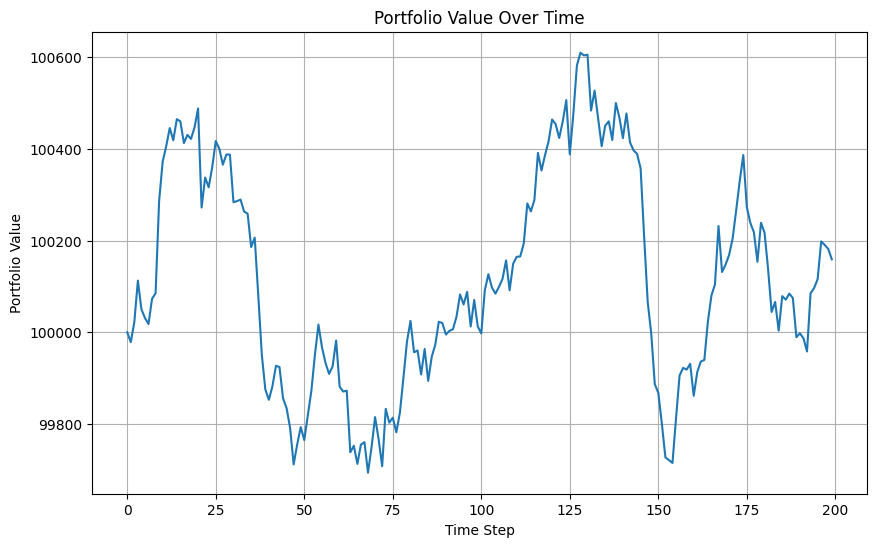

In [ ]:
import numpy as np
import pandas as pd
import gym
from gym import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import matplotlib.pyplot as plt

# Generate dummy multi-asset data
np.random.seed(42)
dates = pd.date_range(start="2020-01-01", periods=200)
data = pd.DataFrame({
    'BTC': np.cumprod(1 + 0.001 * np.random.randn(200)),
    'ETH': np.cumprod(1 + 0.0015 * np.random.randn(200)),
    'AAPL': np.cumprod(1 + 0.0008 * np.random.randn(200)),
    'MSFT': np.cumprod(1 + 0.0009 * np.random.randn(200)),
    'GLD': np.cumprod(1 + 0.0005 * np.random.randn(200)),
    'USO': np.cumprod(1 + 0.001 * np.random.randn(200))
}, index=dates)

# Custom Environment
class MultiAssetEnv(gym.Env):
    def __init__(self, data):
        super(MultiAssetEnv, self).__init__()
        self.data = data
        self.assets = data.columns
        self.n_assets = len(self.assets)
        self.initial_balance = 100000
        self.action_space = spaces.Box(low=0, high=1, shape=(self.n_assets,), dtype=np.float32)
        self.observation_space = spaces.Box(low=0, high=np.inf, shape=(2 * self.n_assets + 1,), dtype=np.float32)

    def reset(self):
        self.current_step = 0
        self.balance = self.initial_balance
        self.asset_held = np.zeros(self.n_assets)
        return self._get_observation()

    def _get_observation(self):
        prices = self.data.iloc[self.current_step].values
        return np.concatenate(([self.balance], self.asset_held, prices))

    def step(self, action):
        prices = self.data.iloc[self.current_step].values
        total_portfolio = self.balance + np.sum(self.asset_held * prices)
        action = action / (np.sum(action) + 1e-8)
        self.asset_held = (action * total_portfolio) / prices
        self.balance = 0

        self.current_step += 1
        done = self.current_step >= len(self.data) - 1

        next_prices = self.data.iloc[self.current_step].values
        portfolio_value = np.sum(self.asset_held * next_prices)
        reward = portfolio_value - total_portfolio
        obs = self._get_observation()
        return obs, reward, done, {}

# Wrap the environment
env = DummyVecEnv([lambda: MultiAssetEnv(data)])

# Train PPO
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=100000)
model.save("ppo_multi_asset")

# Evaluation with clean portfolio logging
eval_env = MultiAssetEnv(data)
obs = eval_env.reset()

portfolio_values = []

for _ in range(len(data) - 1):
    prices = data.iloc[eval_env.current_step].values
    current_value = eval_env.balance + np.sum(eval_env.asset_held * prices)
    portfolio_values.append(current_value)

    action, _ = model.predict(obs)
    obs, _, done, _ = eval_env.step(action)

    if done:
        break

# Add final value
final_prices = data.iloc[eval_env.current_step].values
final_value = eval_env.balance + np.sum(eval_env.asset_held * final_prices)
portfolio_values.append(final_value)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(portfolio_values)
plt.title("Portfolio Value Over Time")
plt.xlabel("Time Step")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()







In [ ]:
!pip install streamlit pyngrok


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.6 MB/s eta 0:00:00


In [ ]:
code = '''
import streamlit as st
import matplotlib.pyplot as plt
import numpy as np

# Dummy portfolio values – replace these with your actual data
env1_values = np.random.normal(100000, 500, 200).cumsum()
env2_values = np.random.normal(100000, 300, 200).cumsum()
env3_values = np.random.normal(100000, 700, 200).cumsum()

st.set_page_config(page_title="RL Trading Dashboard", layout="wide")
st.title("📊 Reinforcement Learning Trading Dashboard")

env_option = st.sidebar.radio("Select Environment", ("Environment 1", "Environment 2", "Environment 3", "Compare All"))

def plot_single_env(values, title, color):
    fig, ax = plt.subplots()
    ax.plot(values, color=color)
    ax.set_title(title)
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Portfolio Value")
    st.pyplot(fig)
    st.success(f"📈 Final Portfolio Value: ${values[-1]:,.2f}")

def plot_all_envs(env1, env2, env3):
    fig, ax = plt.subplots()
    ax.plot(env1, label="Environment 1", color='blue')
    ax.plot(env2, label="Environment 2", color='green')
    ax.plot(env3, label="Environment 3", color='orange')
    ax.set_title("Portfolio Comparison Across Environments")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Portfolio Value")
    ax.legend()
    st.pyplot(fig)
    st.info(f"📌 Final Values:\\n\\n"
            f"- Environment 1: ${env1[-1]:,.2f}\\n"
            f"- Environment 2: ${env2[-1]:,.2f}\\n"
            f"- Environment 3: ${env3[-1]:,.2f}")

if env_option == "Environment 1":
    plot_single_env(env1_values, "Environment 1 Portfolio Value", "blue")
elif env_option == "Environment 2":
    plot_single_env(env2_values, "Environment 2 Portfolio Value", "green")
elif env_option == "Environment 3":
    plot_single_env(env3_values, "Environment 3 Portfolio Value", "orange")
elif env_option == "Compare All":
    plot_all_envs(env1_values, env2_values, env3_values)
'''

with open("dashboard.py", "w") as f:
    f.write(code)


In [ ]:
!ngrok config add-authtoken 2vPl8ajHICA9lxEJKd4XcX6S4Ax_3FJZyF9Qi7jPb2zQEHEuU



Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!pip install streamlit pyngrok --quiet



In [ ]:
!ngrok config add-authtoken 2vPl8ajHICA9lxEJKd4XcX6S4Ax_3FJZyF9Qi7jPb2zQEHEuU


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
%%writefile dashboard.py
import streamlit as st

st.set_page_config(layout="wide")
st.title("📊 RL Trading Strategy Dashboard")
st.markdown("This dashboard will display portfolio performance across all 3 environments.")


Overwriting dashboard.py


In [ ]:
from pyngrok import ngrok
import os

# Kill any existing Streamlit processes
os.system("pkill streamlit")

# Start Streamlit in the background
os.system("streamlit run dashboard.py &")

# Connect with ngrok (new style using http='8501')
public_url = ngrok.connect(8501, "http")
print("🚀 Streamlit is live at:", public_url)


🚀 Streamlit is live at: NgrokTunnel: "https://08ca-34-138-33-2.ngrok-free.app" -> "http://localhost:8501"


In [ ]:
import numpy as np
import pandas as pd
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# Re-generate dummy data for Environment 1
np.random.seed(0)
dates1 = pd.date_range(start="2020-01-01", periods=200)
data1 = pd.DataFrame({
    'BTC': np.cumprod(1 + 0.001 * np.random.randn(200)),
    'ETH': np.cumprod(1 + 0.0012 * np.random.randn(200))
}, index=dates1)

# Recreate the environment
env1_raw = MultiAssetEnv(data1)
env1 = DummyVecEnv([lambda: env1_raw])

# (Re)train or load the model
model1 = PPO("MlpPolicy", env1, verbose=0)
model1.learn(total_timesteps=50000)  # or load with PPO.load("ppo_env1")

# Evaluate and collect portfolio values
portfolio_values_1 = []
obs = env1.reset()

for _ in range(len(data1) - 1):
    action, _ = model1.predict(obs)
    obs, reward, done, _ = env1.step(action)
    step = env1.get_attr('current_step')[0]
    held = env1.get_attr('asset_held')[0]
    price = data1.iloc[step].values
    value = np.sum(held * price)
    portfolio_values_1.append(value)

# Save for Streamlit
np.save("env1_values.npy", portfolio_values_1)




In [ ]:
# Env 2: More volatile crypto data
np.random.seed(1)
dates2 = pd.date_range(start="2021-01-01", periods=200)
data2 = pd.DataFrame({
    'BTC': np.cumprod(1 + 0.002 * np.random.randn(200)),
    'ETH': np.cumprod(1 + 0.0025 * np.random.randn(200)),
    'DOGE': np.cumprod(1 + 0.003 * np.random.randn(200))
}, index=dates2)

# Create Environment
env2_raw = MultiAssetEnv(data2)
env2 = DummyVecEnv([lambda: env2_raw])

# Train or load model
model2 = PPO("MlpPolicy", env2, verbose=0)
model2.learn(total_timesteps=50000)

# Evaluate
portfolio_values_2 = []
obs = env2.reset()

for _ in range(len(data2) - 1):
    action, _ = model2.predict(obs)
    obs, reward, done, _ = env2.step(action)
    step = env2.get_attr('current_step')[0]
    held = env2.get_attr('asset_held')[0]
    price = data2.iloc[step].values
    value = np.sum(held * price)
    portfolio_values_2.append(value)

# Save
np.save("env2_values.npy", portfolio_values_2)


In [ ]:
# Env 3: Crypto + Tech Stocks + Commodities
np.random.seed(2)
dates3 = pd.date_range(start="2022-01-01", periods=200)
data3 = pd.DataFrame({
    'BTC': np.cumprod(1 + 0.0015 * np.random.randn(200)),
    'ETH': np.cumprod(1 + 0.0017 * np.random.randn(200)),
    'AAPL': np.cumprod(1 + 0.0009 * np.random.randn(200)),
    'MSFT': np.cumprod(1 + 0.001 * np.random.randn(200)),
    'GLD': np.cumprod(1 + 0.0006 * np.random.randn(200)),
    'USO': np.cumprod(1 + 0.0008 * np.random.randn(200))
}, index=dates3)

# Create Environment
env3_raw = MultiAssetEnv(data3)
env3 = DummyVecEnv([lambda: env3_raw])

# Train or load model
model3 = PPO("MlpPolicy", env3, verbose=0)
model3.learn(total_timesteps=50000)

# Evaluate
portfolio_values_3 = []
obs = env3.reset()

for _ in range(len(data3) - 1):
    action, _ = model3.predict(obs)
    obs, reward, done, _ = env3.step(action)
    step = env3.get_attr('current_step')[0]
    held = env3.get_attr('asset_held')[0]
    price = data3.iloc[step].values
    value = np.sum(held * price)
    portfolio_values_3.append(value)

# Save
np.save("env3_values.npy", portfolio_values_3)


2025-04-07 19:50:04.834 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-07 19:50:04.838 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-07 19:50:05.186 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-04-07 19:50:05.187 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-07 19:50:05.190 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-07 19:50:05.194 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-07 19:50:05.244 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


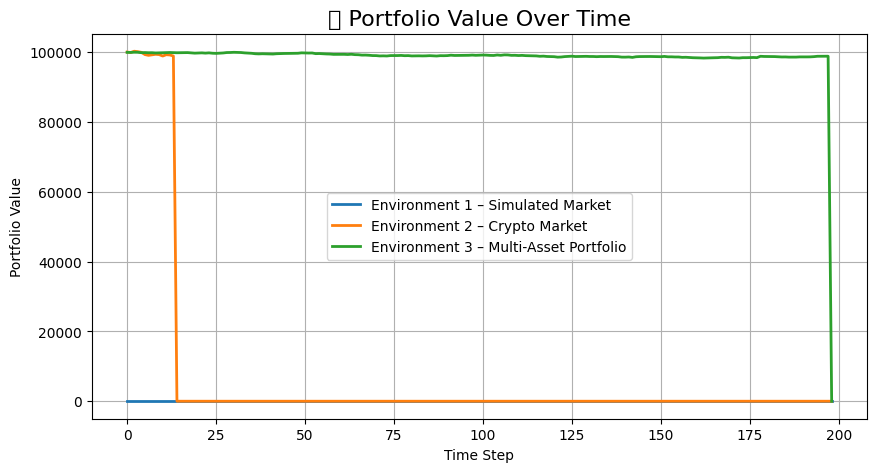

In [ ]:
# dashboard.py
import streamlit as st
import numpy as np
import matplotlib.pyplot as plt

# Load portfolio values
env1_values = np.load("env1_values.npy")
env2_values = np.load("env2_values.npy")
env3_values = np.load("env3_values.npy")

st.set_page_config(page_title="RL Trading Dashboard", layout="centered")
st.title("📈 RL-Based Trading Strategy Performance Dashboard")

st.markdown("Visualizing portfolio growth across **3 environments**: Simulated, Crypto, and Multi-Asset.")

# Plotting
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(env1_values, label="Environment 1 – Simulated Market", linewidth=2)
ax.plot(env2_values, label="Environment 2 – Crypto Market", linewidth=2)
ax.plot(env3_values, label="Environment 3 – Multi-Asset Portfolio", linewidth=2)
ax.set_title("📊 Portfolio Value Over Time", fontsize=16)
ax.set_xlabel("Time Step")
ax.set_ylabel("Portfolio Value")
ax.legend()
ax.grid(True)

st.pyplot(fig)

# Final Value Comparison
st.markdown("### 🔎 Final Portfolio Values")
final_values = {
    "Environment 1": env1_values[-1],
    "Environment 2": env2_values[-1],
    "Environment 3": env3_values[-1]
}

st.bar_chart(final_values)



In [ ]:
!pip install streamlit pyngrok --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.0 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st

st.set_page_config(page_title="RL Dashboard", layout="wide")

st.title("📈 RL Trading Dashboard")
st.markdown("This is a demo Streamlit app for visualizing trading strategy performance.")

st.success("Streamlit app is running successfully!")


Writing app.py


In [ ]:
from pyngrok import ngrok

# Paste your token below 👇
ngrok.set_auth_token("2vPoBTeqOCFeoUUyOpGTtkZY78D_6KSVeL5aiLoKYVQvqGKtm")



In [ ]:
!pip install streamlit pyngrok --quiet


In [ ]:
with open("app.py", "w") as f:
    f.write("""
import streamlit as st

st.set_page_config(page_title="RL Dashboard", layout="wide")
st.title("📊 RL Trading Dashboard")
st.success("Hello Anish! The Streamlit app is running successfully.")
""")


In [ ]:
from pyngrok import ngrok

# Set your Ngrok auth token
ngrok.set_auth_token("2vPoBTeqOCFeoUUyOpGTtkZY78D_6KSVeL5aiLoKYVQvqGKtm")  # 👈 Replace this


In [ ]:
import time

# Kill any existing tunnels
ngrok.kill()

# Start a tunnel on port 8501
public_url = ngrok.connect(8501)
print("🌍 Public URL:", public_url)

# Run the Streamlit app in the background
!streamlit run app.py &

# Wait a few seconds for the app to start
time.sleep(5)


🌍 Public URL: NgrokTunnel: "https://058c-34-74-49-227.ngrok-free.app" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.74.49.227:8501

  Stopping...


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np

# Sample data generator
np.random.seed(42)
dates = pd.date_range(start="2023-01-01", periods=100)
assets = ["BTC", "ETH", "AAPL", "MSFT", "GLD", "USO"]
data = []

for asset in assets:
    price = 100 + np.cumsum(np.random.randn(100))  # random walk
    for date, p in zip(dates, price):
        data.append({"Date": date, "Asset": asset, "Close": p})

# Create DataFrame
df = pd.DataFrame(data)

# Save as CSV
df.to_csv("combined_data.csv", index=False)
print("✅ Sample combined_data.csv created.")


✅ Sample combined_data.csv created.


In [ ]:
import streamlit as st
import pandas as pd
import plotly.express as px

# Load your data
df = pd.read_csv("combined_data.csv")

# Convert 'Date' to datetime if not already
df['Date'] = pd.to_datetime(df['Date'])

# Set page config
st.set_page_config(page_title="📈 Trading Dashboard", layout="wide")

# Title and description
st.title("📊 Portfolio Monitoring Dashboard")
st.markdown("Get insights into the performance of different assets in your trading strategy.")

# Sidebar
st.sidebar.header("🔍 Filter Data")
assets = df["Asset"].unique()
selected_assets = st.sidebar.multiselect("Select Assets", assets, default=list(assets))

# Filter data
filtered_df = df[df["Asset"].isin(selected_assets)]

# Show summary stats
st.subheader("📌 Summary Statistics")
summary = filtered_df.groupby("Asset")["Close"].agg(["mean", "std", "min", "max"]).reset_index()
summary.columns = ["Asset", "Mean Price", "Std Dev", "Min Price", "Max Price"]
st.dataframe(summary.style.format({
    "Mean Price": "{:.2f}",
    "Std Dev": "{:.2f}",
    "Min Price": "{:.2f}",
    "Max Price": "{:.2f}"
}), use_container_width=True)

# Line chart
st.subheader("📈 Price Trends")
fig = px.line(filtered_df, x="Date", y="Close", color="Asset", title="Asset Price Over Time")
st.plotly_chart(fig, use_container_width=True)

# Optionally add image, animations, or more interactivity
with st.expander("💡 Did You Know?"):
    st.info("You can integrate live price updates using APIs like Yahoo Finance or Alpha Vantage.")

# Footer
st.markdown("---")
st.markdown("Made with ❤️ using Streamlit on Google Colab")


2025-04-08 05:54:42.681 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-08 05:54:42.682 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-08 05:54:42.683 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-08 05:54:42.684 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-08 05:54:42.685 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-08 05:54:42.686 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-08 05:54:42.687 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-08 05:54:42.689 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [ ]:
# Step 1: Write your Streamlit app
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np

st.set_page_config(page_title="RL Portfolio Dashboard", layout="wide")

# Sample data if you don't have a CSV yet
assets = ["BTC", "ETH", "AAPL", "MSFT", "GLD", "USO"]
data = {
    "Date": pd.date_range(start="2024-01-01", periods=30).tolist() * len(assets),
    "Asset": sum([[a]*30 for a in assets], []),
    "Close": np.random.uniform(100, 1000, size=30*len(assets))
}
df = pd.DataFrame(data)

# Sidebar filters
st.sidebar.header("Filter Options")
selected_assets = st.sidebar.multiselect("Select Assets", df["Asset"].unique(), default=df["Asset"].unique())
date_range = st.sidebar.date_input("Date Range", [df["Date"].min(), df["Date"].max()])

# Filter data
filtered_df = df[
    (df["Asset"].isin(selected_assets)) &
    (df["Date"] >= pd.to_datetime(date_range[0])) &
    (df["Date"] <= pd.to_datetime(date_range[1]))
]

# Dashboard layout
st.title("📊 Portfolio Performance Overview")
st.write("Filtered data view:")

summary = filtered_df.groupby("Asset")["Close"].agg(["mean", "std", "min", "max"]).reset_index()
summary.columns = ["Asset", "Mean Price", "Std Dev", "Min Price", "Max Price"]

# Format numbers properly
st.dataframe(summary.style.format({
    "Mean Price": "{:.2f}",
    "Std Dev": "{:.2f}",
    "Min Price": "{:.2f}",
    "Max Price": "{:.2f}"
}), use_container_width=True)

# Line chart
st.line_chart(filtered_df.pivot(index="Date", columns="Asset", values="Close"))



Overwriting app.py


In [ ]:
import threading
import time
import os

# Run Streamlit in the background
def run_streamlit():
    os.system("streamlit run app.py")

thread = threading.Thread(target=run_streamlit)
thread.start()

# Wait a few seconds to make sure streamlit starts
time.sleep(5)

# Create public tunnel
public_url = ngrok.connect(8501)
print("🌐 Public URL:", public_url)



🌐 Public URL: NgrokTunnel: "https://98cf-34-74-49-227.ngrok-free.app" -> "http://localhost:8501"
